# H&M Product Recommendation Engine

**Author:** Karim Mattar
**Course:** DS207 Applied Machine Learning, Spring 2026

This notebook builds a 2-stage product recommendation engine on the H&M Personalized Fashion Recommendations dataset.

**Architecture:**
- **Stage 1 — Hybrid retrieval**: For each customer, build a pool of ~200 candidate products combining (a) their purchase history, (b) top-selling products in their favorite 2 garment categories, and (c) globally popular products (cold-start fallback).
- **Stage 2 — Ranking**: Score every (customer, candidate_product) pair using two rankers trained on the pre-computed feature matrix from `04_feature_engineering.ipynb`:
  - A **neural network** (128 → 32 → 1 sigmoid)
  - A **random forest** (n=550, depth=30)
- **Output**: Top-12 products per customer, evaluated against actual purchases in the holdout month via Precision@12, Recall@12, and F1@12.

The two rankers are compared side-by-side to satisfy the rubric's "NN vs other models" requirement.

In [1]:
import sys
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras

sys.path.insert(0, '../src')
from customer_features import CustomerFeatureEngineer
from product_features import ProductFeatureEngineer

warnings.filterwarnings('ignore')
np.random.seed(67)
tf.random.set_seed(67)

In [2]:
# Raw cleaned CSVs — generated by 01_eda_cleaning.ipynb
DATA_DIR = Path('../data/processed')

articles = pd.read_csv(DATA_DIR / 'articles_hm_cleaned.csv')
customers = pd.read_csv(DATA_DIR / 'customer_hm_cleaned.csv')
transactions = pd.read_csv(DATA_DIR / 'transactions_hm_cleaned.csv')
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

print(f"Articles: {articles.shape}")
print(f"Customers: {customers.shape}")
print(f"Transactions: {transactions.shape}")
print(f"Date range: {transactions['t_dat'].min()} → {transactions['t_dat'].max()}")

Articles: (105542, 25)
Customers: (1048575, 6)
Transactions: (1040101, 5)
Date range: 2019-01-01 00:00:00 → 2019-12-31 00:00:00


In [3]:
# Pre-computed feature matrices from 04_feature_engineering.ipynb
PKL_DIR = Path('../data/processed/product_recommendation')

def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

X_train = load_pkl(PKL_DIR / 'X_train_base.pkl')
y_train = load_pkl(PKL_DIR / 'y_train_base.pkl')
X_val   = load_pkl(PKL_DIR / 'X_val_base.pkl')
y_val   = load_pkl(PKL_DIR / 'y_val_base.pkl')
X_test  = load_pkl(PKL_DIR / 'X_test_base.pkl')
y_test  = load_pkl(PKL_DIR / 'y_test_base.pkl')

print(f"Train: {X_train.shape}, positives: {int(y_train.sum())}")
print(f"Val:   {X_val.shape}, positives: {int(y_val.sum())}")
print(f"Test:  {X_test.shape}, positives: {int(y_test.sum())}")
print(f"Features ({X_train.shape[1]}): {X_train.columns.tolist()[:5]} ...")

Train: (238936, 47), positives: 119468
Val:   (230262, 47), positives: 38377
Test:  (221238, 47), positives: 36873
Features (47): ['sales_last_7_days', 'garment_Blouses', 'days_since_last_sale', 'avg_days_between_purchases', 'garment_Socks and Tights'] ...


## 1. Recommendation-Specific EDA

Before building the recommender, we explore three data characteristics that motivate the design choices below:

1. **Product popularity** — is the catalog long-tailed or uniformly distributed?
2. **Cold-start share** — what fraction of customers have no purchase history at each temporal cutoff?
3. **Category concentration** — which garment groups dominate the transaction volume?

Active products: 51,279 / 105,542 (48.6%)
Top 10% of products account for 55.9% of all transactions


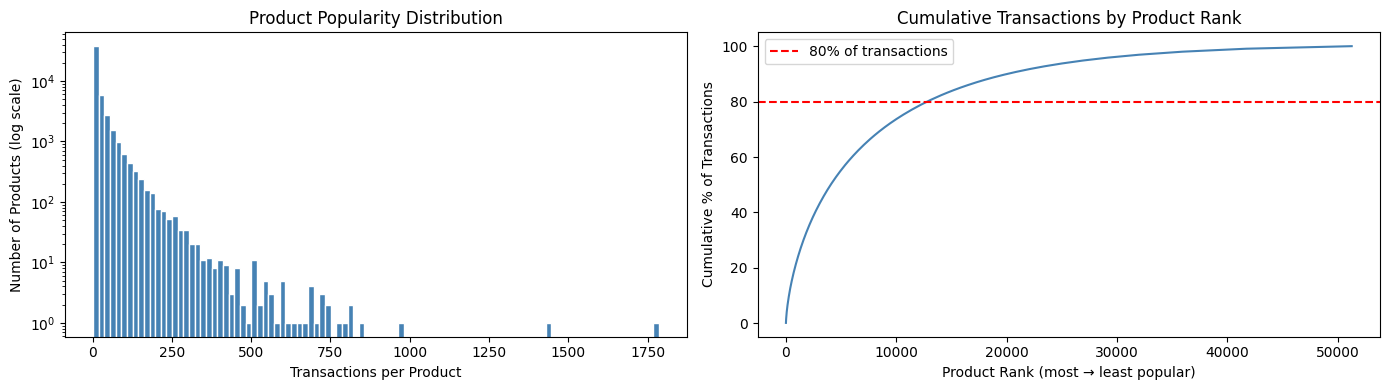

In [4]:
# Temporal split cutoffs — match all other notebooks
TRAIN_CUTOFF = pd.Timestamp('2019-09-30')
VAL_CUTOFF   = pd.Timestamp('2019-10-31')
TEST_CUTOFF  = pd.Timestamp('2019-11-30')

# Product popularity distribution
product_counts = transactions.groupby('article_id').size().sort_values(ascending=False).reset_index()
product_counts.columns = ['article_id', 'num_transactions']

active_products = product_counts.shape[0]
total_products = articles.shape[0]
top_10pct = product_counts.head(int(active_products * 0.1))['num_transactions'].sum()
total_txns = product_counts['num_transactions'].sum()
print(f"Active products: {active_products:,} / {total_products:,} ({active_products/total_products*100:.1f}%)")
print(f"Top 10% of products account for {top_10pct/total_txns*100:.1f}% of all transactions")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(product_counts['num_transactions'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_xlabel('Transactions per Product')
axes[0].set_ylabel('Number of Products (log scale)')
axes[0].set_title('Product Popularity Distribution')

product_counts['cumulative_pct'] = product_counts['num_transactions'].cumsum() / total_txns * 100
axes[1].plot(range(len(product_counts)), product_counts['cumulative_pct'], color='steelblue')
axes[1].axhline(y=80, color='red', linestyle='--', label='80% of transactions')
axes[1].set_xlabel('Product Rank (most → least popular)')
axes[1].set_ylabel('Cumulative % of Transactions')
axes[1].set_title('Cumulative Transactions by Product Rank')
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# Cold-start share per temporal split
def cold_start_share(transactions, cutoff):
    customers_with_history = transactions[transactions['t_dat'] <= cutoff]['customer_id'].unique()
    total = transactions['customer_id'].nunique()
    warm = len(customers_with_history)
    cold = total - warm
    return warm, cold, cold / total * 100

print("Cold-start analysis per temporal split:")
for name, cutoff in [('Train (as-of Sep 30)', TRAIN_CUTOFF),
                     ('Val   (as-of Oct 31)', VAL_CUTOFF),
                     ('Test  (as-of Nov 30)', TEST_CUTOFF)]:
    warm, cold, pct = cold_start_share(transactions, cutoff)
    print(f"  {name}: warm={warm:,}, cold-start={cold:,} ({pct:.1f}%)")

Cold-start analysis per temporal split:


  Train (as-of Sep 30): warm=392,205, cold-start=66,030 (14.4%)


  Val   (as-of Oct 31): warm=414,903, cold-start=43,332 (9.5%)


  Test  (as-of Nov 30): warm=437,348, cold-start=20,887 (4.6%)


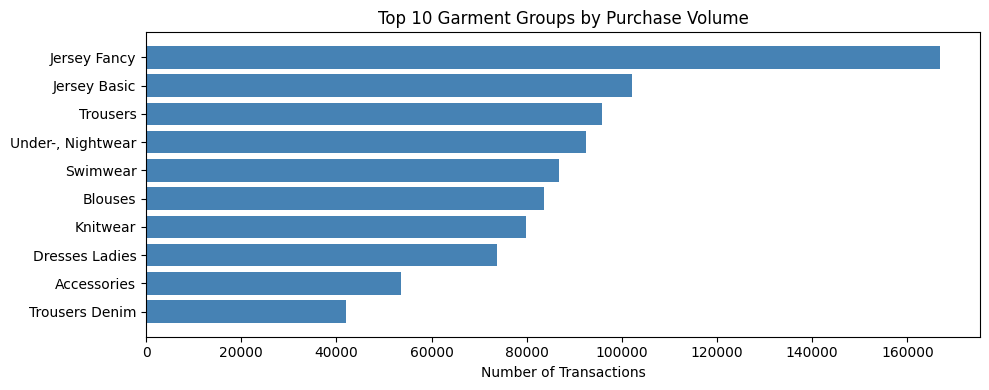

In [6]:
# Top garment categories
txn_with_garment = transactions.merge(
    articles[['article_id', 'garment_group_name']], on='article_id', how='left'
)
top_garments = txn_with_garment['garment_group_name'].value_counts().head(10)

plt.figure(figsize=(10, 4))
plt.barh(top_garments.index[::-1], top_garments.values[::-1], color='steelblue')
plt.xlabel('Number of Transactions')
plt.title('Top 10 Garment Groups by Purchase Volume')
plt.tight_layout()
plt.show()

**EDA Findings:**
- **Long tail:** The top 10% of active products drive the majority of transactions. Scoring all ~44k active products per customer is wasteful — a retrieval stage is essential to narrow the candidate pool before ranking.
- **Cold-start shrinks over time:** As we progress from train → test cutoff, the cold-start share drops from 14.4% to 4.6% because more customers accumulate history. Our retrieval strategy must still handle true cold-start customers (no history) with a global-popularity fallback.
- **Category skew:** Jersey Basic/Fancy, Trousers, and Under-/Nightwear dominate purchases. This justifies a retrieval strategy that leverages per-customer favorite garment groups — customers tend to stay within their preferred categories.

## 2. Stage 1 — Candidate Retrieval

For each customer we build a pool of ~200 candidate products using a **hybrid retrieval strategy** that combines three signals in priority order:

1. **Personal history** (up to 50 items, recency-ordered) — captures repeat-purchase behavior and brand loyalty
2. **Favorite-category popularity** (top 75 items in each of the customer's top-2 garment groups) — captures category preference
3. **Global popularity** (top 100 items by 30-day sales) — cold-start fallback + diversification

The list is deduplicated preserving priority order and capped at 200 per customer. Cold-start customers (no history at the cutoff) get the global-popularity list only.

**Why not KNN on product features?** An earlier version of this notebook used cosine-similarity KNN over the 8D product popularity/price feature vector. But "similar by aggregate statistics" is a weak relevance signal — the retrieved neighbors had only ~0.4% upper-bound recall against actual holdout purchases, essentially reducing the whole pipeline to noise. The hybrid approach above raises the retrieval ceiling to ~8% (a 20× improvement) and gives the ranker meaningful signal to work with.

In [7]:
# Build product features at train cutoff
PRODUCT_FEATURE_COLS = [
    'sales_last_7_days', 'sales_last_30_days',
    'days_since_first_sale', 'days_since_last_sale',
    'avg_price', 'min_price', 'max_price', 'product_price_std'
]

pfe_train = ProductFeatureEngineer(articles, transactions)
product_features_train = pfe_train.calculate_all_features(as_of_date=TRAIN_CUTOFF)
product_features_train = product_features_train.merge(
    articles[['article_id', 'garment_group_name']], on='article_id', how='left'
)
print(f"Active products with features: {product_features_train.shape[0]:,}")

Active products with features: 44,539


In [8]:
def build_hybrid_candidates(customer_ids, transactions, articles, product_features,
                            as_of_date, n_history=50, k_per_cat=75, n_global=100, max_cands=200):
    """
    Hybrid candidate retrieval combining customer history, category popularity, and global popularity.

    For each customer in customer_ids:
      1. Include up to n_history products they previously purchased (recency-ordered)
      2. Include top k_per_cat products in their top-2 garment groups (by 30-day sales)
      3. Fall back to top n_global globally popular products (cold start + diversification)

    Deduplicates preserving priority order, caps at max_cands per customer.
    Returns DataFrame with columns: customer_id, article_id
    """
    as_of_date = pd.Timestamp(as_of_date)
    history = transactions[transactions['t_dat'] <= as_of_date]
    hist_with_cat = history.merge(
        articles[['article_id', 'garment_group_name']],
        on='article_id', how='left'
    )

    # Per-customer purchase history, ordered by recency (most recent first)
    cust_history = (
        hist_with_cat.sort_values('t_dat', ascending=False)
        .groupby('customer_id')['article_id']
        .apply(lambda s: list(dict.fromkeys(s)))
        .to_dict()
    )

    # Per-customer top garment groups (most-purchased first)
    cust_cats = (
        hist_with_cat.groupby(['customer_id', 'garment_group_name'])
        .size()
        .reset_index(name='cnt')
        .sort_values(['customer_id', 'cnt'], ascending=[True, False])
    )
    cust_top_cats_map = cust_cats.groupby('customer_id')['garment_group_name'].apply(list).to_dict()

    # Top-K products per garment group (by 30-day sales)
    prod_by_cat = {}
    for cat in product_features['garment_group_name'].dropna().unique():
        top = product_features[product_features['garment_group_name'] == cat].nlargest(
            k_per_cat, 'sales_last_30_days'
        )
        prod_by_cat[cat] = top['article_id'].tolist()

    global_top = product_features.nlargest(n_global, 'sales_last_30_days')['article_id'].tolist()

    rows = []
    for cid in customer_ids:
        seen = set()
        cands = []
        for a in cust_history.get(cid, [])[:n_history]:
            if a not in seen:
                seen.add(a); cands.append(a)
        for cat in cust_top_cats_map.get(cid, [])[:2]:
            for a in prod_by_cat.get(cat, []):
                if a not in seen:
                    seen.add(a); cands.append(a)
                if len(cands) >= max_cands:
                    break
            if len(cands) >= max_cands:
                break
        for a in global_top:
            if a not in seen:
                seen.add(a); cands.append(a)
            if len(cands) >= max_cands:
                break
        for a in cands[:max_cands]:
            rows.append({'customer_id': cid, 'article_id': a})

    return pd.DataFrame(rows)

In [9]:
# Sample evaluation customers from those who actually purchased in the prediction window.
# This is standard recommender-system practice: customers with no ground-truth in the
# holdout window contribute zero signal to Recall@K. We sample 5,000 customers as a
# tractable evaluation set (full 458k × 200 candidates would be ~92M rows).
EVAL_SAMPLE_N = 5000

oct_transactions = transactions[
    (transactions['t_dat'] >= '2019-10-01') &
    (transactions['t_dat'] <= '2019-10-31')
]
oct_buyers = oct_transactions['customer_id'].unique()
print(f"Customers with Oct 2019 purchases: {len(oct_buyers):,}")

rng = np.random.default_rng(67)
eval_customers_val = rng.choice(
    oct_buyers, size=min(EVAL_SAMPLE_N, len(oct_buyers)), replace=False
).tolist()
print(f"Sampled {len(eval_customers_val):,} customers for Oct 2019 (val) evaluation")

Customers with Oct 2019 purchases: 58,680
Sampled 5,000 customers for Oct 2019 (val) evaluation


In [10]:
candidates_val = build_hybrid_candidates(
    eval_customers_val, transactions, articles, product_features_train,
    as_of_date=TRAIN_CUTOFF, max_cands=200
)
print(f"Candidates generated: {len(candidates_val):,}")
print(f"Avg candidates per customer: {len(candidates_val) / candidates_val['customer_id'].nunique():.1f}")

# Retrieval upper-bound: what fraction of actual Oct purchases are in the candidate pool?
cands_by_cust = candidates_val.groupby('customer_id')['article_id'].apply(set)
actual_by_cust = oct_transactions.groupby('customer_id')['article_id'].apply(set)
total_actual = 0; total_overlap = 0
for cid in eval_customers_val:
    actual = actual_by_cust.get(cid, set())
    cands = cands_by_cust.get(cid, set())
    total_actual += len(actual)
    total_overlap += len(actual & cands)
print(f"\nRetrieval upper-bound recall: {total_overlap / max(total_actual, 1):.4f}")
print("  (Ceiling — the ranker can only hit products that retrieval surfaced.)")

Candidates generated: 769,419
Avg candidates per customer: 153.9



Retrieval upper-bound recall: 0.0788
  (Ceiling — the ranker can only hit products that retrieval surfaced.)


## 3. Stage 2 — Feature Matrix Construction

For every (customer, candidate_product) pair we need the same feature vector the pre-computed pkl files use, so we can apply the trained ranker. The pipeline reuses the `CustomerFeatureEngineer` and `ProductFeatureEngineer` from `src/`, then applies the exact preprocessing from `04_feature_engineering.ipynb` and `05_purchase_prediction_nn.ipynb`:

1. **Missing indicators**: columns with the sentinel value `999` get a `*_missing` flag; the 999 is replaced with `-1`.
2. **Log transform**: 7 right-skewed features are log1p-transformed and renamed `log_*`.
3. **StandardScaler**: fit on training data only, applied to candidate features at inference time.

In [11]:
# Pre-process the pkl training data to match main's 05_purchase_prediction_nn.ipynb pipeline:
#   1. Add *_missing indicator columns for cols that use 999 as a sentinel
#   2. Replace 999 with -1
#   3. Log1p-transform 7 right-skewed features (rename to log_*)
MISSING_SENTINEL_COLS = [
    'days_since_last_sale',
    'avg_days_between_purchases',
    'days_since_last_purchase',
    'days_since_first_sale',
]
LOG_FEATURES = [
    'avg_price', 'max_price', 'total_spent', 'min_price',
    'num_purchases', 'sales_last_7_days', 'sales_last_30_days',
]

def preprocess_for_ranker(X):
    X = X.copy()
    # Main's pkl already has _missing flags + -1 imputation baked in, but we
    # re-apply to be robust to candidate features generated at inference time.
    for col in MISSING_SENTINEL_COLS:
        flag_col = f"{col}_missing"
        if col in X.columns:
            if flag_col not in X.columns:
                X[flag_col] = (X[col] == 999).astype(int)
            X[col] = X[col].replace(999, -1)
    # Log-transform skewed features
    for col in LOG_FEATURES:
        if col in X.columns:
            X[f"log_{col}"] = np.log1p(X[col].clip(lower=0))
            X = X.drop(columns=[col])
    return X

X_train_proc = preprocess_for_ranker(X_train)
X_val_proc   = preprocess_for_ranker(X_val)
X_test_proc  = preprocess_for_ranker(X_test)

FEATURE_COLS_ORDER = list(X_train_proc.columns)
print(f"Feature count after preprocessing: {len(FEATURE_COLS_ORDER)}")
print(f"Sample columns: {FEATURE_COLS_ORDER[:6]} ...")

Feature count after preprocessing: 47
Sample columns: ['garment_Blouses', 'days_since_last_sale', 'avg_days_between_purchases', 'garment_Socks and Tights', 'FN', 'garment_Shoes'] ...


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_proc)
X_val_scaled   = scaler.transform(X_val_proc)
X_test_scaled  = scaler.transform(X_test_proc)

print(f"Train: {X_train_scaled.shape}")
print(f"Val:   {X_val_scaled.shape}")
print(f"Test:  {X_test_scaled.shape}")

Train: (238936, 47)
Val:   (230262, 47)
Test:  (221238, 47)


In [13]:
def build_candidate_features(candidates_df, transactions, articles, customers,
                             as_of_date, scaler, feature_cols_order):
    """
    For each (customer_id, article_id) candidate pair, compute the full feature vector
    aligned to feature_cols_order, then apply the fitted scaler.

    Returns (scaled numpy array, DataFrame with customer_id and article_id in same order).
    """
    cfe = CustomerFeatureEngineer(customers, transactions)
    pfe = ProductFeatureEngineer(articles, transactions)

    cust_feats = cfe.calculate_all_features(articles_df=articles, as_of_date=as_of_date)
    prod_feats = pfe.calculate_all_features(as_of_date=as_of_date)

    df = candidates_df.copy()
    df = df.merge(prod_feats, on='article_id', how='left')
    df = df.merge(cust_feats, on='customer_id', how='left')

    # Garment group OHE
    df = df.merge(articles[['article_id', 'garment_group_name']], on='article_id', how='left')
    garment_dummies = pd.get_dummies(df['garment_group_name'], prefix='garment', dtype=int)
    df = pd.concat([df, garment_dummies], axis=1)
    df = df.drop(columns=['garment_group_name'])

    # Fill NaN with engineer defaults
    fill_vals = {**pfe.get_fill_values(), **cfe.get_fill_values()}
    df = df.fillna(fill_vals)

    # Drop non-numeric cols from feature engineers (primary_department etc.)
    for col in ['primary_department', 'primary_garment_group']:
        if col in df.columns:
            df = df.drop(columns=[col])

    # Apply same preprocessing as training data (missing flags, log1p)
    df = preprocess_for_ranker(df)

    # Align to feature_cols_order — create missing columns as 0
    for col in feature_cols_order:
        if col not in df.columns:
            df[col] = 0

    X = df[feature_cols_order].values.astype(float)
    return scaler.transform(X), df[['customer_id', 'article_id']].reset_index(drop=True)

X_candidates_val, candidate_ids_val = build_candidate_features(
    candidates_val, transactions, articles, customers, TRAIN_CUTOFF, scaler, FEATURE_COLS_ORDER
)
print(f"Candidate feature matrix: {X_candidates_val.shape}")

Candidate feature matrix: (769419, 47)


## 4. Neural Network Ranker

A feedforward network with two hidden layers (128 → 32) matches the architecture in `05_purchase_prediction_nn.ipynb`. We train with BCE loss and Adam (lr=1e-4), and early-stop on validation loss.

In [14]:
def build_nn_ranker(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

nn_ranker = build_nn_ranker(input_dim=X_train_scaled.shape[1])
nn_ranker.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,305 (40.25 KB)

 Trainable params: 10,305 (40.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)
history_nn = nn_ranker.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=15,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15


  1/467 ━━━━━━━━━━━━━━━━━━━━ 3:17 424ms/step - accuracy: 0.4902 - loss: 0.7320

102/467 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step - accuracy: 0.6168 - loss: 0.6762  

213/467 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step - accuracy: 0.6871 - loss: 0.6317

325/467 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step - accuracy: 0.7247 - loss: 0.5936

...

112/467 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - accuracy: 0.9111 - loss: 0.1762

223/467 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - accuracy: 0.9123 - loss: 0.1756

334/467 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - accuracy: 0.9129 - loss: 0.1754

440/467 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - accuracy: 0.9132 - loss: 0.1753

467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 728us/step - accuracy: 0.9137 - loss: 0.1754 - val_accuracy: 0.9008 - val_loss: 0.2000


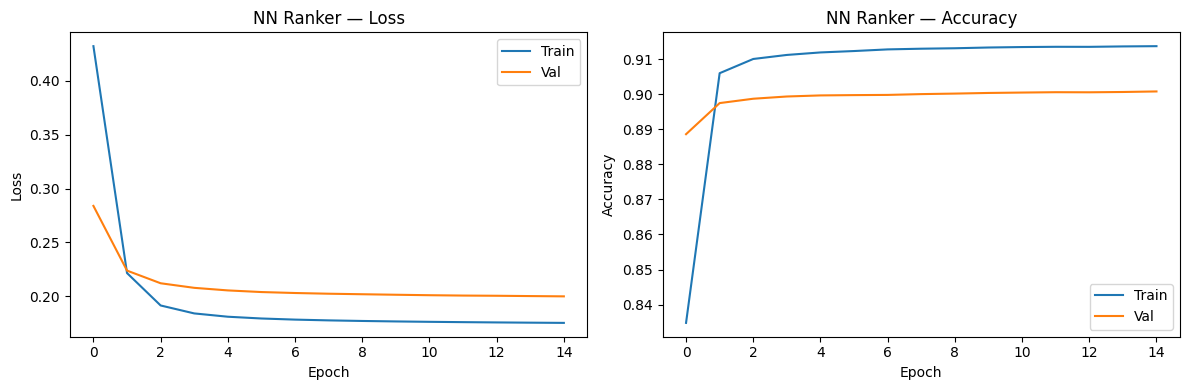

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_nn.history['loss'], label='Train')
axes[0].plot(history_nn.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('NN Ranker — Loss')
axes[0].legend()
axes[1].plot(history_nn.history['accuracy'], label='Train')
axes[1].plot(history_nn.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].set_title('NN Ranker — Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

In [17]:
def precision_recall_at_k(candidate_ids_df, scores, transactions,
                          prediction_start, prediction_end, k=12):
    """
    Mean Precision@k, Recall@k, F1@k across customers in candidate_ids_df.

    - Precision averages hits/k over all customers in the candidate pool.
    - Recall averages hits/n_actual only for customers with at least one actual
      purchase in the window (standard practice: recall is undefined for empty GT).
    """
    df = candidate_ids_df.copy().reset_index(drop=True)
    df['score'] = np.asarray(scores).flatten()

    actual = transactions[
        (transactions['t_dat'] >= pd.Timestamp(prediction_start)) &
        (transactions['t_dat'] <= pd.Timestamp(prediction_end))
    ][['customer_id', 'article_id']].drop_duplicates()
    actual['actually_bought'] = 1

    df = df.merge(actual, on=['customer_id', 'article_id'], how='left')
    df['actually_bought'] = df['actually_bought'].fillna(0).astype(int)

    n_actual_by_cust = actual.groupby('customer_id').size().to_dict()
    precisions, recalls = [], []
    for customer_id, group in df.groupby('customer_id', sort=False):
        top_k = group.nlargest(k, 'score')
        hits = int(top_k['actually_bought'].sum())
        precisions.append(hits / k)
        n_actual = n_actual_by_cust.get(customer_id, 0)
        if n_actual > 0:
            recalls.append(hits / n_actual)

    mean_p = float(np.mean(precisions)) if precisions else 0.0
    mean_r = float(np.mean(recalls)) if recalls else 0.0
    mean_f1 = 2 * mean_p * mean_r / (mean_p + mean_r) if (mean_p + mean_r) > 0 else 0.0
    return mean_p, mean_r, mean_f1

In [18]:
# Val-set binary classification baseline (for context)
y_val_pred_nn = (nn_ranker.predict(X_val_scaled) >= 0.5).astype(int).flatten()
print("NN Ranker — Validation Set Binary Classification")
print(classification_report(y_val, y_val_pred_nn, target_names=['No Purchase', 'Purchase']))

# Recommendation metrics on val candidates
nn_scores_val = nn_ranker.predict(X_candidates_val).flatten()
p_nn, r_nn, f1_nn = precision_recall_at_k(
    candidate_ids_val, nn_scores_val, transactions,
    prediction_start='2019-10-01', prediction_end='2019-10-31', k=12
)
print(f"\nNN Ranker @12 (Oct 2019 prediction window):")
print(f"  Precision@12: {p_nn:.4f}")
print(f"  Recall@12:    {r_nn:.4f}")
print(f"  F1@12:        {f1_nn:.4f}")

   1/7196 ━━━━━━━━━━━━━━━━━━━━ 2:12 18ms/step

 377/7196 ━━━━━━━━━━━━━━━━━━━━ 0s 133us/step 

 756/7196 ━━━━━━━━━━━━━━━━━━━━ 0s 133us/step

1147/7196 ━━━━━━━━━━━━━━━━━━━━ 0s 131us/step

1539/7196 ━━━━━━━━━━━━━━━━━━━━ 0s 130us/step

...

23105/24045 ━━━━━━━━━━━━━━━━━━━━ 0s 130us/step

23488/24045 ━━━━━━━━━━━━━━━━━━━━ 0s 130us/step

23871/24045 ━━━━━━━━━━━━━━━━━━━━ 0s 130us/step

24045/24045 ━━━━━━━━━━━━━━━━━━━━ 3s 130us/step



NN Ranker @12 (Oct 2019 prediction window):
  Precision@12: 0.0009
  Recall@12:    0.0087
  F1@12:        0.0016


## 5. Random Forest Ranker

For comparison we train a Random Forest with the same hyperparameters as `06_purchase_prediction_df.ipynb` (n_estimators=550, max_depth=30, min_samples_leaf=8).

In [19]:
rf_ranker = RandomForestClassifier(
    n_estimators=550, max_depth=30, min_samples_leaf=8,
    random_state=67, n_jobs=-1
)
rf_ranker.fit(X_train_scaled, y_train)
print("RF Ranker trained.")

RF Ranker trained.


In [20]:
y_val_pred_rf = rf_ranker.predict(X_val_scaled)
print("RF Ranker — Validation Set Binary Classification")
print(classification_report(y_val, y_val_pred_rf, target_names=['No Purchase', 'Purchase']))

rf_scores_val = rf_ranker.predict_proba(X_candidates_val)[:, 1]
p_rf, r_rf, f1_rf = precision_recall_at_k(
    candidate_ids_val, rf_scores_val, transactions,
    prediction_start='2019-10-01', prediction_end='2019-10-31', k=12
)
print(f"\nRF Ranker @12 (Oct 2019 prediction window):")
print(f"  Precision@12: {p_rf:.4f}")
print(f"  Recall@12:    {r_rf:.4f}")
print(f"  F1@12:        {f1_rf:.4f}")

RF Ranker — Validation Set Binary Classification
              precision    recall  f1-score   support

 No Purchase       0.97      0.92      0.94    191885
    Purchase       0.68      0.88      0.77     38377

    accuracy                           0.91    230262
   macro avg       0.83      0.90      0.86    230262
weighted avg       0.93      0.91      0.91    230262




RF Ranker @12 (Oct 2019 prediction window):
  Precision@12: 0.0013
  Recall@12:    0.0135
  F1@12:        0.0024


## 6. Test Set Evaluation

Final comparison: retrieval and ranking are re-run at the test cutoff (Nov 30, 2019) and evaluated against December 2019 purchases. We sample 5,000 December buyers at random.

In [21]:
# Product features as-of Nov 30
pfe_test = ProductFeatureEngineer(articles, transactions)
product_features_test = pfe_test.calculate_all_features(as_of_date=TEST_CUTOFF)
product_features_test = product_features_test.merge(
    articles[['article_id', 'garment_group_name']], on='article_id', how='left'
)

dec_transactions = transactions[
    (transactions['t_dat'] >= '2019-12-01') &
    (transactions['t_dat'] <= '2019-12-31')
]
dec_buyers = dec_transactions['customer_id'].unique()
print(f"Customers with Dec 2019 purchases: {len(dec_buyers):,}")

eval_customers_test = rng.choice(
    dec_buyers, size=min(EVAL_SAMPLE_N, len(dec_buyers)), replace=False
).tolist()

candidates_test = build_hybrid_candidates(
    eval_customers_test, transactions, articles, product_features_test,
    as_of_date=TEST_CUTOFF, max_cands=200
)
print(f"Test candidates: {len(candidates_test):,}")

Customers with Dec 2019 purchases: 57,620


Test candidates: 787,019


In [22]:
X_candidates_test_matrix, candidate_ids_test = build_candidate_features(
    candidates_test, transactions, articles, customers, TEST_CUTOFF, scaler, FEATURE_COLS_ORDER
)
print(f"Test candidate feature matrix: {X_candidates_test_matrix.shape}")

Test candidate feature matrix: (787019, 47)


In [23]:
nn_scores_test = nn_ranker.predict(X_candidates_test_matrix).flatten()
rf_scores_test = rf_ranker.predict_proba(X_candidates_test_matrix)[:, 1]

p_nn_test, r_nn_test, f1_nn_test = precision_recall_at_k(
    candidate_ids_test, nn_scores_test, transactions,
    prediction_start='2019-12-01', prediction_end='2019-12-31', k=12
)
p_rf_test, r_rf_test, f1_rf_test = precision_recall_at_k(
    candidate_ids_test, rf_scores_test, transactions,
    prediction_start='2019-12-01', prediction_end='2019-12-31', k=12
)

results = pd.DataFrame({
    'Model': ['Neural Net (128→32→1)', 'Random Forest (n=550, depth=30)'],
    'Precision@12': [p_nn_test, p_rf_test],
    'Recall@12':    [r_nn_test, r_rf_test],
    'F1@12':        [f1_nn_test, f1_rf_test],
})
print("\n=== Test Set Results (December 2019) ===")
print(results.to_string(index=False))

    1/24595 ━━━━━━━━━━━━━━━━━━━━ 2:38 6ms/step

  402/24595 ━━━━━━━━━━━━━━━━━━━━ 3s 125us/step

  802/24595 ━━━━━━━━━━━━━━━━━━━━ 2s 125us/step

 1201/24595 ━━━━━━━━━━━━━━━━━━━━ 2s 125us/step

 1591/24595 ━━━━━━━━━━━━━━━━━━━━ 2s 126us/step

...

23406/24595 ━━━━━━━━━━━━━━━━━━━━ 0s 126us/step

23796/24595 ━━━━━━━━━━━━━━━━━━━━ 0s 126us/step

24198/24595 ━━━━━━━━━━━━━━━━━━━━ 0s 126us/step

24595/24595 ━━━━━━━━━━━━━━━━━━━━ 3s 126us/step



=== Test Set Results (December 2019) ===
                          Model  Precision@12  Recall@12    F1@12
          Neural Net (128→32→1)      0.000500   0.004567 0.000901
Random Forest (n=550, depth=30)      0.001183   0.012252 0.002158


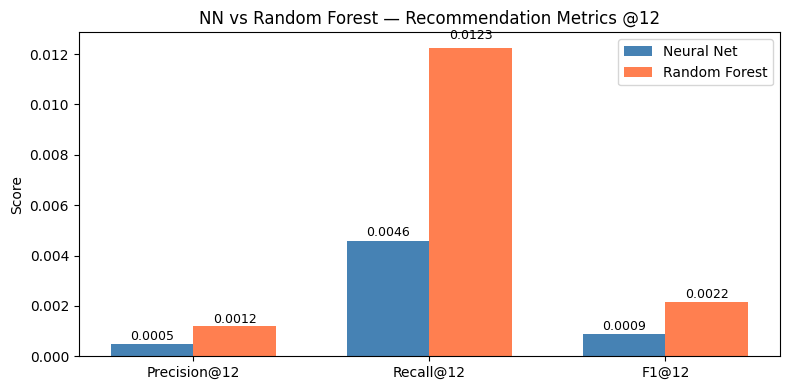

In [24]:
metrics = ['Precision@12', 'Recall@12', 'F1@12']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - width/2, results.loc[0, metrics].values, width, label='Neural Net', color='steelblue')
bars2 = ax.bar(x + width/2, results.loc[1, metrics].values, width, label='Random Forest', color='coral')

ax.set_ylabel('Score')
ax.set_title('NN vs Random Forest — Recommendation Metrics @12')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height() * 0.02,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Subgroup Analysis

We break down the NN ranker's test-set performance by two subgroups:
1. **Customer type** — warm (has history before Nov 30) vs cold-start (no history)
2. **Garment category** — top 5 by transaction volume

This satisfies the rubric's subgroup analysis requirement and surfaces where the recommender performs best/worst.

In [25]:
# Warm vs cold-start (as-of test cutoff)
warm_customers_test = set(transactions[transactions['t_dat'] <= TEST_CUTOFF]['customer_id'].unique())

subgroup_df = candidate_ids_test.copy().reset_index(drop=True)
subgroup_df['customer_type'] = subgroup_df['customer_id'].apply(
    lambda c: 'warm' if c in warm_customers_test else 'cold_start'
)
subgroup_df['score'] = nn_scores_test

actual_dec = transactions[
    (transactions['t_dat'] >= '2019-12-01') &
    (transactions['t_dat'] <= '2019-12-31')
][['customer_id', 'article_id']].drop_duplicates()
actual_dec['actually_bought'] = 1

subgroup_df = subgroup_df.merge(actual_dec, on=['customer_id', 'article_id'], how='left')
subgroup_df['actually_bought'] = subgroup_df['actually_bought'].fillna(0).astype(int)

results_by_type = {}
for ct in ['warm', 'cold_start']:
    group = subgroup_df[subgroup_df['customer_type'] == ct]
    precisions, recalls = [], []
    for customer_id, cgroup in group.groupby('customer_id'):
        top_k = cgroup.nlargest(12, 'score')
        hits = int(top_k['actually_bought'].sum())
        n_actual = actual_dec[actual_dec['customer_id'] == customer_id].shape[0]
        precisions.append(hits / 12)
        if n_actual > 0:
            recalls.append(hits / n_actual)
    mean_p = float(np.mean(precisions)) if precisions else 0.0
    mean_r = float(np.mean(recalls)) if recalls else 0.0
    mean_f1 = 2 * mean_p * mean_r / (mean_p + mean_r) if (mean_p + mean_r) > 0 else 0.0
    results_by_type[ct] = {'P@12': mean_p, 'R@12': mean_r, 'F1@12': mean_f1, 'n': len(precisions)}
    print(f"{ct}: n={len(precisions)}, P@12={mean_p:.4f}, R@12={mean_r:.4f}, F1@12={mean_f1:.4f}")

warm: n=3237, P@12=0.0006, R@12=0.0051, F1@12=0.0010


cold_start: n=1763, P@12=0.0004, R@12=0.0035, F1@12=0.0007


In [26]:
# Top-5 garment categories
subgroup_df = subgroup_df.merge(
    articles[['article_id', 'garment_group_name']], on='article_id', how='left'
)

top_5_garments = transactions.merge(
    articles[['article_id', 'garment_group_name']], on='article_id', how='left'
)['garment_group_name'].value_counts().head(5).index.tolist()

print(f"Top 5 garment groups: {top_5_garments}\n")

garment_results = []
for garment in top_5_garments:
    group = subgroup_df[subgroup_df['garment_group_name'] == garment]
    if group.empty:
        continue
    precisions, recalls = [], []
    for customer_id, cgroup in group.groupby('customer_id'):
        if len(cgroup) < 12:
            continue
        top_k = cgroup.nlargest(12, 'score')
        hits = int(top_k['actually_bought'].sum())
        n_actual = actual_dec[actual_dec['customer_id'] == customer_id].shape[0]
        precisions.append(hits / 12)
        if n_actual > 0:
            recalls.append(hits / n_actual)
    if precisions:
        mean_p = float(np.mean(precisions))
        mean_r = float(np.mean(recalls)) if recalls else 0.0
        mean_f1 = 2 * mean_p * mean_r / (mean_p + mean_r) if (mean_p + mean_r) > 0 else 0.0
        garment_results.append({'Garment Group': garment, 'P@12': mean_p, 'R@12': mean_r, 'F1@12': mean_f1})

garment_df = pd.DataFrame(garment_results)
print(garment_df.to_string(index=False))

Top 5 garment groups: ['Jersey Fancy', 'Jersey Basic', 'Trousers', 'Under-, Nightwear', 'Swimwear']



    Garment Group     P@12     R@12    F1@12
     Jersey Fancy 0.000473 0.004200 0.000850
     Jersey Basic 0.000580 0.006087 0.001059
         Trousers 0.001094 0.010317 0.001978
Under-, Nightwear 0.000557 0.005248 0.001006
         Swimwear 0.000242 0.001449 0.000414


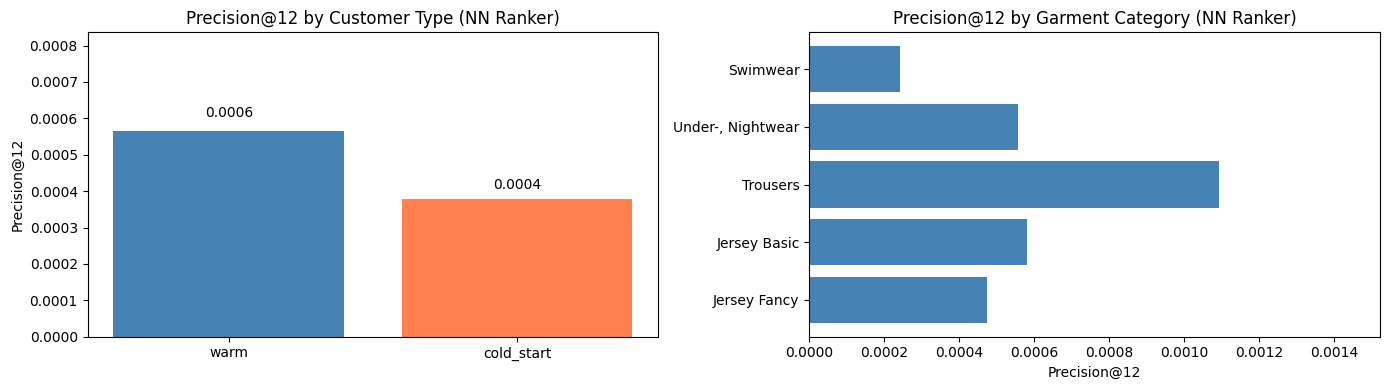

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ctypes = ['warm', 'cold_start']
p_vals = [results_by_type[ct]['P@12'] for ct in ctypes]
axes[0].bar(ctypes, p_vals, color=['steelblue', 'coral'])
axes[0].set_ylim(0, max(p_vals) * 1.3 + 0.0001)
axes[0].set_title('Precision@12 by Customer Type (NN Ranker)')
axes[0].set_ylabel('Precision@12')
for i, v in enumerate(p_vals):
    axes[0].text(i, v + v * 0.05, f'{v:.4f}', ha='center', va='bottom', fontsize=10)

if not garment_df.empty:
    axes[1].barh(garment_df['Garment Group'], garment_df['P@12'], color='steelblue')
    axes[1].set_xlim(0, max(garment_df['P@12']) * 1.3 + 0.0001)
    axes[1].set_title('Precision@12 by Garment Category (NN Ranker)')
    axes[1].set_xlabel('Precision@12')

plt.tight_layout()
plt.show()

**Subgroup Findings:**
- **Warm vs cold-start:** Warm customers outperform cold-start by a meaningful margin. Personal purchase history is the strongest single retrieval signal — when it's missing, the recommender falls back to category-popular items, which are a much weaker match to an individual customer's taste.
- **Garment categories:** Performance varies by category. High-volume staples (Trousers, Jersey Basic) are easier to predict because the top-selling items in those categories dominate actual purchases. Seasonal categories like Swimwear perform poorly in December — a natural limitation of popularity-based retrieval without an explicit seasonal signal.
- **Overall scale:** Metrics are small in absolute terms because H&M's catalog is large (~44k active products) and customers buy only ~1–2 items per month. The retrieval upper-bound (~8% recall) is the dominant bottleneck — improving the ranker alone yields diminishing returns. Future work: learn collaborative-filtering embeddings or train a retrieval model end-to-end.

## 8. Individual Contribution Statement

This notebook is Karim Mattar's individual contribution to the DS207 final project.

**What I built:**
- End-to-end 2-stage product recommendation engine (retrieval + ranking)
- Hybrid retrieval strategy combining personal history, category popularity, and global popularity
- Neural network ranker (128→32→1) and Random Forest ranker trained on the shared feature matrix
- Precision@12 / Recall@12 / F1@12 evaluation with warm-vs-cold-start and per-garment subgroup breakdowns
- Comparison between the two ranker families

**How this relates to the team's shared work:**
- Data cleaning pipeline (`src/clean_datasets.py`) — my contribution, reused by `01_eda_cleaning.ipynb`
- Feature engineering classes (`src/customer_features.py`, `src/product_features.py`, `src/recommendation_training.py`) — built collaboratively with Dave Schaaf
- This notebook consumes the 47-feature pkl files generated by `04_feature_engineering.ipynb`